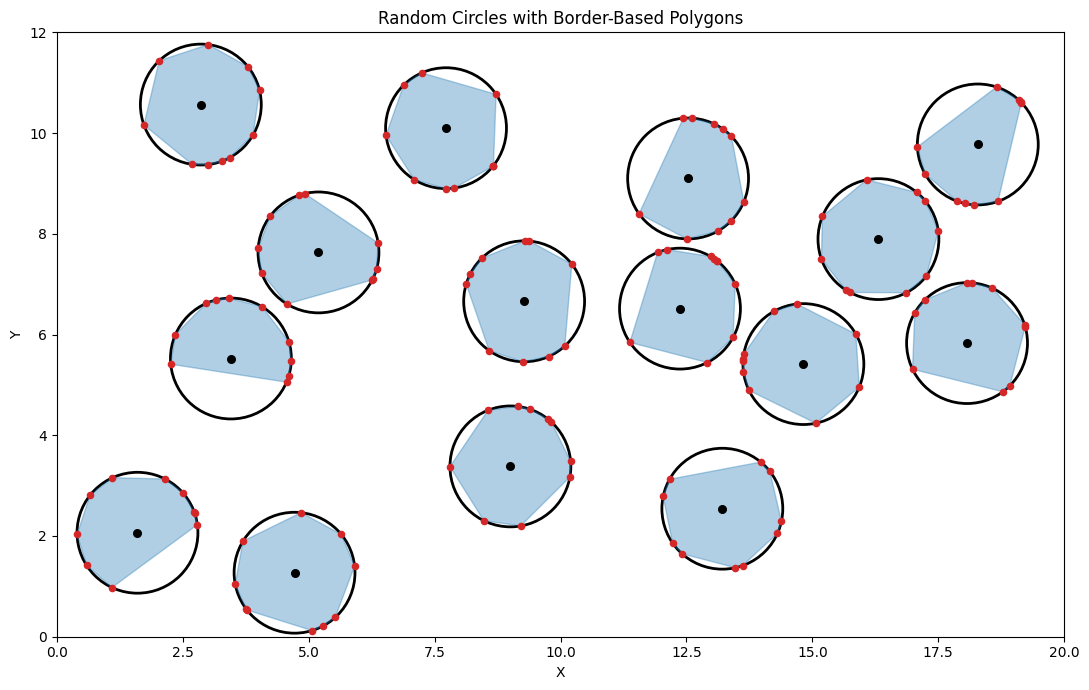

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Polygon

# ----------------------------
# Parameters
# ----------------------------
WIDTH = 20
HEIGHT = 12
RADIUS = 1.2
N_CIRCLES = 15
N_POINTS = 10
SEED = 42
MIN_GAP = 0.15

rng = np.random.default_rng(SEED)

# ----------------------------
# Helpers
# ----------------------------
def circles_overlap(c1, c2, radius, min_gap=0.0):
    x1, y1 = c1
    x2, y2 = c2
    return np.hypot(x2 - x1, y2 - y1) < (2 * radius + min_gap)

def generate_non_overlapping_centers(width, height, radius, n_circles, min_gap=0.15, max_tries=10000):
    centers = []
    tries = 0

    while len(centers) < n_circles and tries < max_tries:
        tries += 1
        x = rng.uniform(radius, width - radius)
        y = rng.uniform(radius, height - radius)
        candidate = (x, y)

        if all(not circles_overlap(candidate, c, radius, min_gap=min_gap) for c in centers):
            centers.append(candidate)

    if len(centers) < n_circles:
        raise RuntimeError(f'Could only place {len(centers)} circles after {max_tries} attempts.')

    return np.array(centers)

def border_polygon_points(center, radius, n_points):
    cx, cy = center

    # Random angles around the border
    angles = np.sort(rng.uniform(0, 2 * np.pi, n_points))

    # Points exactly on the circle border
    xs = cx + radius * np.cos(angles)
    ys = cy + radius * np.sin(angles)

    return np.column_stack([xs, ys])

# ----------------------------
# Generate data
# ----------------------------
centers = generate_non_overlapping_centers(WIDTH, HEIGHT, RADIUS, N_CIRCLES, MIN_GAP)
polygons = [border_polygon_points(c, RADIUS, N_POINTS) for c in centers]

# ----------------------------
# Plot
# ----------------------------
fig, ax = plt.subplots(figsize=(12, 7))
ax.set_xlim(0, WIDTH)
ax.set_ylim(0, HEIGHT)
ax.set_aspect('equal', adjustable='box')
ax.set_title('Random Circles with Border-Based Polygons')
ax.set_xlabel('X')
ax.set_ylabel('Y')

for center, pts in zip(centers, polygons):
    cx, cy = center

    circle = Circle((cx, cy), RADIUS, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(circle)

    poly = Polygon(pts, closed=True, fill=True, alpha=0.35,
                   edgecolor='tab:blue', facecolor='tab:blue')
    ax.add_patch(poly)

    ax.scatter(pts[:, 0], pts[:, 1], s=20, color='tab:red', zorder=3)

ax.scatter(centers[:, 0], centers[:, 1], s=30, color='black', zorder=4)
plt.tight_layout()
plt.show()